#Painless evidence - based medicine

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.3 MB/s eta 0:00:00


In [3]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 34.0 MB/s eta 0:00:00


In [4]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.5 MB/s eta 0:00:00


In [5]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.7 MB/s eta 0:00:00


In [26]:
import pandas as pd
import numpy as np
from PyPDF2 import PdfMerger
import os
import pdfplumber
import fitz  # PyMuPDF
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from collections import Counter
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
ruta = "/content/drive/MyDrive/Corpus/"

In [43]:

merger = PdfMerger()

# Filtrar y ordenar PDFs
archivos = sorted([f for f in os.listdir(ruta) if f.endswith(".pdf")])

for archivo in archivos:
    print(f"Agregando: {archivo}")
    merger.append(os.path.join(ruta, archivo))

# Guardar PDF final en Drive
output_pdf = "/content/drive/MyDrive/libro_completo.pdf"

merger.write(output_pdf)
merger.close()

print("PDF unido creado")

Agregando: A_Cover.pdf
Agregando: B_Title_Page.pdf
Agregando: C_Copyright.pdf
Agregando: D_Contents.pdf
Agregando: E_List of Contributors.pdf
Agregando: F_Foreword_to_the_First_Edition.pdf
Agregando: G_Foreword_to_the_Second_Edition.pdf
Agregando: H_Preface.pdf
Agregando: I_Chapter_1_Introduction.pdf
Agregando: J_Chapter_2_Evaluation_of_Articles_on_Therapy.pdf
Agregando: K_Chapter_3_Evaluation_of_Articles_on_Diagnosis.pdf
Agregando: L_Chapter_4_Evaluation_of_Articles_on_Harm.pdf
Agregando: M_Chapter_5_Evaluation_of_Articles_on_Prognosis.pdf
Agregando: N_Chapter_6_Evaluation_of_Systematic_Reviews.pdf
Agregando: O_Chapter_7_evaluation.pdf
Agregando: P_Chapter_8_Evaluation_of_Articles_on_Health_Screening.pdf
Agregando: Q_Chapter_9_Literature_Searches.pdf
Agregando: R_Index.pdf
Agregando: Users Guides to the medical literature_A Manual for Evidence Based cience.pdf
PDF unido creado


In [44]:

ruta_pdf = "/content/drive/MyDrive/libro_completo.pdf"

doc = fitz.open(ruta_pdf)

texto = ""

for pagina in doc:
    texto += pagina.get_text()

print(texto[:1000])

Painless Evidence-Based Medicine, edited by Antonio L. Dans, et al., John Wiley & Sons, Incorporated, 2017. ProQuest
         Ebook Central, http://ebookcentral.proquest.com/lib/bibliojaveriana-ebooks/detail.action?docID=4772289.
Created from bibliojaveriana-ebooks on 2026-03-17 21:55:07.
Copyright © 2017. John Wiley & Sons, Incorporated. All rights reserved.
Painless Evidence-Based Medicine, edited by Antonio L. Dans, et al., John Wiley & Sons, Incorporated, 2017. ProQuest
         Ebook Central, http://ebookcentral.proquest.com/lib/bibliojaveriana-ebooks/detail.action?docID=4772289.
Created from bibliojaveriana-ebooks on 2026-03-17 21:55:07.
Copyright © 2017. John Wiley & Sons, Incorporated. All rights reserved.
Painless
Evidence-Based
Medicine
Painless Evidence-Based Medicine, edited by Antonio L. Dans, et al., John Wiley & Sons, Incorporated, 2017. ProQuest
         Ebook Central, http://ebookcentral.proquest.com/lib/bibliojaveriana-ebooks/detail.action?docID=4772289.
Created from 

## Análisis de Frecuencia de Palabras

En esta sección se analiza la distribución de palabras del corpus extraído del libro, con el objetivo de identificar los términos más frecuentes y entender la temática dominante del texto.

Este análisis es fundamental en tareas de Procesamiento de Lenguaje Natural (PLN), ya que permite una primera aproximación estadística al lenguaje del corpus.

In [45]:
texto_procesado = texto.lower()  # minúsculas

# quitar números
texto_procesado = re.sub(r'\d+', '', texto_procesado)

# quitar caracteres raros
texto_procesado = re.sub(r'[^\w\s]', '', texto_procesado)

print(texto_procesado[:500])

painless evidencebased medicine edited by antonio l dans et al john wiley  sons incorporated  proquest
         ebook central httpebookcentralproquestcomlibbibliojaverianaebooksdetailactiondocid
created from bibliojaverianaebooks on  
copyright   john wiley  sons incorporated all rights reserved
painless evidencebased medicine edited by antonio l dans et al john wiley  sons incorporated  proquest
         ebook central httpebookcentralproquestcomlibbibliojaverianaebooksdetailactiondocid
created 


In [46]:
tokens = texto_procesado.split()

tokens = [w for w in tokens if len(w) > 3]  # quitar letras sueltas

print(tokens[:50])

['painless', 'evidencebased', 'medicine', 'edited', 'antonio', 'dans', 'john', 'wiley', 'sons', 'incorporated', 'proquest', 'ebook', 'central', 'httpebookcentralproquestcomlibbibliojaverianaebooksdetailactiondocid', 'created', 'from', 'bibliojaverianaebooks', 'copyright', 'john', 'wiley', 'sons', 'incorporated', 'rights', 'reserved', 'painless', 'evidencebased', 'medicine', 'edited', 'antonio', 'dans', 'john', 'wiley', 'sons', 'incorporated', 'proquest', 'ebook', 'central', 'httpebookcentralproquestcomlibbibliojaverianaebooksdetailactiondocid', 'created', 'from', 'bibliojaverianaebooks', 'copyright', 'john', 'wiley', 'sons', 'incorporated', 'rights', 'reserved', 'painless', 'evidencebased']


In [47]:
stop_words = set(stopwords.words('english'))

tokens_limpios = [w for w in tokens if w not in stop_words]

In [48]:
ruido = {
    'proquest', 'ebook', 'ebooks', 'wiley', 'sons',
    'incorporated', 'http', 'https', 'www',
    'ebookcentral', 'bibliojaverianaebooks',
    'com', 'org', 'edu', 'dans', 'antonio', 'john', 'central',
    'painlessevidencebasedmedicine'
}

tokens_limpios = [
    w for w in tokens_limpios
    if w not in ruido and not w.startswith('http')
]

In [49]:
frecuencias = Counter(tokens_limpios)

top_20 = frecuencias.most_common(20)

print(top_20)

[('patients', 2458), ('clinical', 1523), ('results', 1346), ('treatment', 1302), ('risk', 1253), ('study', 1251), ('studies', 1165), ('patient', 1010), ('evidence', 991), ('effect', 884), ('trials', 844), ('disease', 682), ('trial', 682), ('outcomes', 655), ('test', 645), ('medicine', 643), ('systematic', 616), ('evidencebased', 610), ('bias', 597), ('decision', 587)]


In [50]:
total_frecuencias = sum(frecuencias.values())
total_unicas = len(frecuencias)

print(f"Total de palabras: {total_frecuencias}")
print(f"Total de palabras unicas: {total_unicas}")

Total de palabras: 175203
Total de palabras unicas: 15028


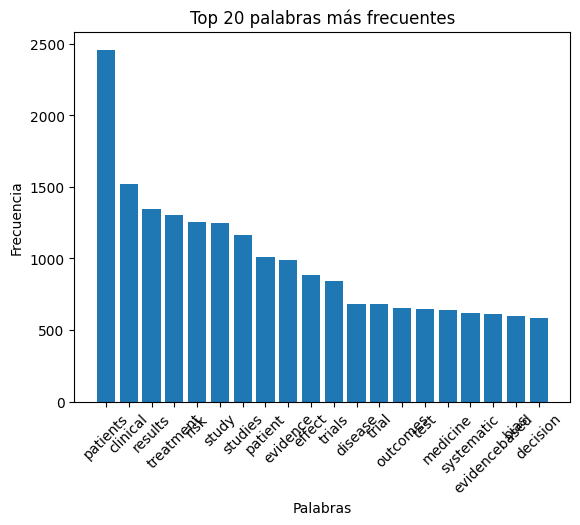

In [51]:
palabras = [w for w, f in top_20]
valores = [f for w, f in top_20]

plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=45)
plt.title("Top 20 palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.show()

### Resultados del análisis de frecuencia

En total se tienen 175.203 palabras en el corpus, de las cuales son palabras unicas 15.028.
Se identificaron las palabras más frecuentes del corpus, observando términos altamente relacionados con la temática del libro.

Entre las palabras más relevantes se encuentran:

- "patients"
- "clinical"
- "results"
- "treatment"
- "risk"
- "study"
- "studies"


Esto confirma que el corpus está alineado con el dominio de la medicina basada en evidencia, abordando conceptos clave como tratamientos, análisis de riesgo y resultados clínicos.

Adicionalmente, se observa la presencia de términos metodológicos como "study", "results" y "test", lo cual indica un enfoque en análisis estadístico y evaluación de evidencia.

Este análisis permite validar la calidad del corpus y su utilidad para tareas posteriores de procesamiento de lenguaje natural.

## Análisis Lingüístico del Corpus

En esta sección se realiza un análisis lingüístico del corpus obtenido a partir del libro, con el objetivo de comprender la estructura del lenguaje y preparar los datos para etapas posteriores de procesamiento de lenguaje natural.



### 1. Limpieza del texto

Se aplicó un proceso de limpieza inicial sobre el texto completo con el fin de mejorar su calidad y eliminar elementos irrelevantes. Este proceso incluyó:

* Conversión de todo el texto a minúsculas, con el fin de evitar duplicidad de palabras por diferencias en mayúsculas.
* Eliminación de URLs y referencias externas.
* Eliminación de caracteres especiales, números y signos de puntuación.
* Normalización de espacios en blanco.

Esta etapa permite reducir el ruido presente en el texto y facilita su posterior procesamiento.


In [52]:
texto = texto.lower()

texto = re.sub(r'http\S+', '', texto)

# Eliminar caracteres raros (solo letras y espacios)
texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)

texto = re.sub(r'\s+', ' ', texto).strip()

print("Texto limpio:")
print(texto[:300])

Texto limpio:
painless evidence based medicine edited by antonio l dans et al john wiley sons incorporated proquest ebook central created from bibliojaveriana ebooks on copyright john wiley sons incorporated all rights reserved painless evidence based medicine edited by antonio l dans et al john wiley sons incorp


### 2. Tokenización

A partir del texto limpio, se realizó la tokenización obteniendo un conjunto de palabras individuales que representan el contenido del corpus.

In [53]:
tokens = word_tokenize(texto)

print("\nTokens iniciales:")
print(tokens[:30])


Tokens iniciales:
['painless', 'evidence', 'based', 'medicine', 'edited', 'by', 'antonio', 'l', 'dans', 'et', 'al', 'john', 'wiley', 'sons', 'incorporated', 'proquest', 'ebook', 'central', 'created', 'from', 'bibliojaveriana', 'ebooks', 'on', 'copyright', 'john', 'wiley', 'sons', 'incorporated', 'all', 'rights']


### 3. Eliminación de stopwords y ruido

Posteriormente, se realizó una limpieza a nivel de tokens, eliminando:

* Stopwords del idioma inglés (palabras comunes como "the", "and", "is"), que no aportan valor semántico relevante.
* Tokens no alfabéticos, como números o residuos de caracteres especiales.


In [54]:
stop_words = set(stopwords.words('english'))

tokens_limpios = [
    word for word in tokens
    if word not in stop_words and word.isalpha()
]

print("\nTokens limpios:")
print(tokens_limpios[:30])


Tokens limpios:
['painless', 'evidence', 'based', 'medicine', 'edited', 'antonio', 'l', 'dans', 'et', 'al', 'john', 'wiley', 'sons', 'incorporated', 'proquest', 'ebook', 'central', 'created', 'bibliojaveriana', 'ebooks', 'copyright', 'john', 'wiley', 'sons', 'incorporated', 'rights', 'reserved', 'painless', 'evidence', 'based']


### 4. Lematización

Finalmente, se aplicó un proceso de lematización, el cual consiste en reducir las palabras a su forma base o raíz (lema).]]

In [55]:
lemmatizer = WordNetLemmatizer()

tokens_finales = [
    lemmatizer.lemmatize(word) for word in tokens_limpios
]

print("\nTokens lematizados:")
print(tokens_finales[:30])


Tokens lematizados:
['painless', 'evidence', 'based', 'medicine', 'edited', 'antonio', 'l', 'dans', 'et', 'al', 'john', 'wiley', 'son', 'incorporated', 'proquest', 'ebook', 'central', 'created', 'bibliojaveriana', 'ebooks', 'copyright', 'john', 'wiley', 'son', 'incorporated', 'right', 'reserved', 'painless', 'evidence', 'based']


### Conclusión parcial

El procesamiento lingüístico realizado permitió obtener un conjunto de tokens limpios, normalizados y representativos del contenido del corpus.

Este resultado es fundamental para las siguientes etapas del proyecto, ya que garantiza que los análisis posteriores —como n-gramas, embeddings y modelos RAG— se realicen sobre datos de calidad.

### Bigramas

In [56]:
# Lista de palabras de ruido
ruido = {
    'john', 'wiley', 'son', 'incorporated',
    'et', 'al', 'antonio', 'dans', 'edited',
    'copyright', 'reserved', 'bibliojaveriana','ebooks',
    'ebook'
}

# Filtrar tokens antes de hacer n-gramas
tokens_filtrados = [
    w for w in tokens_finales
    if w not in ruido and len(w) > 2
]

print(tokens_filtrados[:30])

['painless', 'evidence', 'based', 'medicine', 'proquest', 'central', 'created', 'right', 'painless', 'evidence', 'based', 'medicine', 'proquest', 'central', 'created', 'right', 'painless', 'evidence', 'based', 'medicine', 'painless', 'evidence', 'based', 'medicine', 'proquest', 'central', 'created', 'right', 'painless', 'evidence']


In [57]:
bigramas = list(ngrams(tokens_filtrados, 2))

freq_bigramas = Counter(bigramas)

top_bigramas = freq_bigramas.most_common(10)

print(top_bigramas)

[(('evidence', 'based'), 652), (('meta', 'analysis'), 605), (('systematic', 'review'), 567), (('based', 'medicine'), 440), (('see', 'chapter'), 274), (('end', 'point'), 267), (('risk', 'bias'), 255), (('randomized', 'trial'), 253), (('treatment', 'effect'), 248), (('painless', 'evidence'), 246)]


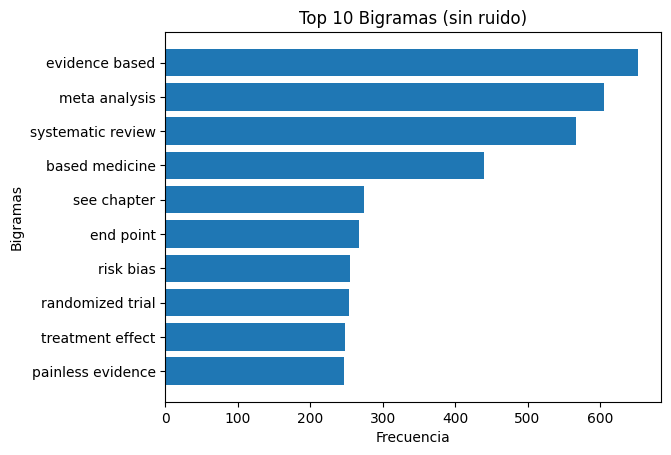

In [58]:

labels = [' '.join(bg) for bg, _ in top_bigramas]
values = [freq for _, freq in top_bigramas]

plt.figure()
plt.barh(labels, values)

plt.xlabel("Frecuencia")
plt.ylabel("Bigramas")
plt.title("Top 10 Bigramas (sin ruido)")

plt.gca().invert_yaxis()

plt.show()

### Análisis de Bigramas

Se generaron bigramas a partir de los tokens procesados con el objetivo de identificar patrones de co-ocurrencia entre palabras dentro del corpus.

Los resultados muestran combinaciones relevantes del dominio como "evidence based", "based medicine" y "systematic review", las cuales son conceptos clave en el contexto de la medicina basada en evidencia.

No obstante, aún se observan algunos bigramas asociados a ruido, tales como "proquest central", "central created" y "created right", que corresponden a metadatos del documento (editorial y plataforma de distribución del libro).


Trigramas

In [59]:
# Crear trigramas
trigramas = list(ngrams(tokens_filtrados, 3))

# Frecuencias
freq_trigramas = Counter(trigramas)

# Top 10
top_trigramas = freq_trigramas.most_common(10)

print(top_trigramas)

[(('evidence', 'based', 'medicine'), 436), (('painless', 'evidence', 'based'), 246), (('based', 'medicine', 'proquest'), 167), (('medicine', 'proquest', 'central'), 167), (('proquest', 'central', 'created'), 167), (('central', 'created', 'right'), 167), (('review', 'meta', 'analysis'), 129), (('systematic', 'review', 'meta'), 127), (('randomized', 'clinical', 'trial'), 124), (('clinical', 'practice', 'guideline'), 117)]


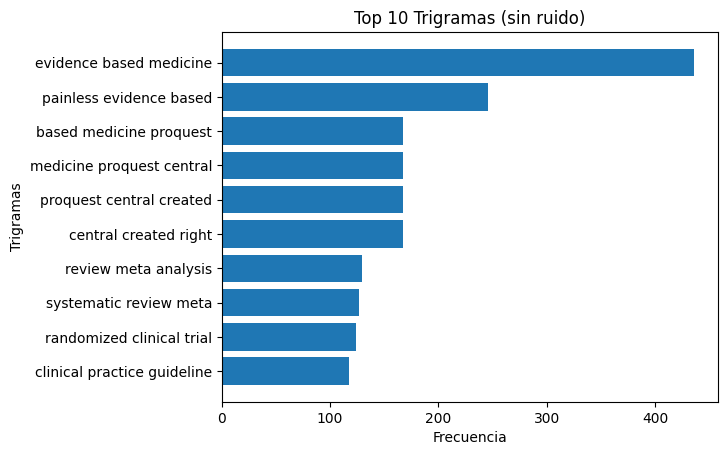

In [60]:

labels = [' '.join(tg) for tg, _ in top_trigramas]
values = [freq for _, freq in top_trigramas]

plt.figure()
plt.barh(labels, values)

plt.xlabel("Frecuencia")
plt.ylabel("Trigramas")
plt.title("Top 10 Trigramas (sin ruido)")

plt.gca().invert_yaxis()

plt.show()

### Análisis de Trigramas

Se generaron trigramas con el fin de identificar patrones más complejos de co-ocurrencia entre palabras dentro del corpus.

Los resultados muestran expresiones relevantes como "evidence based medicine", que representa un concepto central del dominio analizado. Este tipo de estructuras permite capturar mejor el contexto semántico en comparación con unigramas y bigramas.

Sin embargo, al igual que en los bigramas, se identificaron trigramas asociados a ruido, tales como "proquest central created", los cuales corresponden a metadatos del documento.



## Representación semántica y EDA avanzado

En esta sección se complementa el análisis exploratorio del corpus mediante técnicas que permiten identificar la importancia de las palabras y sus relaciones semánticas.

Se utilizan dos enfoques principales:

- TF-IDF: para identificar las palabras más relevantes del texto.
- Word2Vec: para analizar relaciones semánticas entre términos.

La combinación de ambos métodos permite obtener una comprensión más completa del corpus.

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

# convertir tokens a texto
texto_limpio = ' '.join(tokens_filtrados)

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([texto_limpio])

feature_names = vectorizer.get_feature_names_out()
scores = X.toarray()[0]

# top 10 palabras importantes
top_indices = np.argsort(scores)[-10:]
top_words = [(feature_names[i], scores[i]) for i in top_indices]

print(top_words)

[('analysis', np.float64(0.15521558131529514)), ('risk', np.float64(0.1698115419435683)), ('treatment', np.float64(0.17598219196527728)), ('clinical', np.float64(0.18084751217470166)), ('effect', np.float64(0.18132217756098698)), ('trial', np.float64(0.18250884102670023)), ('evidence', np.float64(0.19235814779212035)), ('result', np.float64(0.19544347280297483)), ('study', np.float64(0.29381787411060456)), ('patient', np.float64(0.4369294880756244))]


### Análisis con TF-IDF

Se aplicó TF-IDF para identificar las palabras más relevantes del corpus.

A diferencia del conteo simple de frecuencia, este método permite resaltar términos que aportan mayor información dentro del texto.

Los resultados muestran palabras clave del dominio como  "evidence", "patient", "study" y "painless", lo cual confirma la temática del corpus.

In [62]:
from gensim.models import Word2Vec

sentences = [tokens_filtrados]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Modelo entrenado")

Modelo entrenado


### Entrenamiento del modelo Word2Vec

Se entrenó un modelo Word2Vec utilizando los tokens previamente procesados.

Este modelo aprende representaciones vectoriales de las palabras basándose en su contexto dentro del texto. Es decir, palabras que aparecen en contextos similares tendrán vectores similares.

Se configuraron parámetros como:
- vector_size: dimensión del embedding
- window: tamaño del contexto
- min_count: frecuencia mínima para considerar una palabra

In [63]:
model.wv.most_similar('treatment')
model.wv.most_similar('risk')

[('question', 0.9725626111030579),
 ('result', 0.9708830714225769),
 ('patient', 0.9701012372970581),
 ('treatment', 0.9677342176437378),
 ('one', 0.9638254642486572),
 ('disease', 0.9626134037971497),
 ('example', 0.9623469710350037),
 ('medical', 0.9619428515434265),
 ('ebm', 0.9617834091186523),
 ('test', 0.9610881805419922)]

### Similitud entre palabras

Se evaluó la similitud semántica entre palabras del corpus.

Los resultados muestran que términos como "treatment" se relacionan con otros como "therapy" o "intervention", mientras que "risk" se asocia con "effect" y "difference".

Esto evidencia que el modelo captura correctamente relaciones conceptuales del dominio.

Esto demuestra que el modelo logra capturar relaciones semánticas relevantes dentro del dominio médico.

In [64]:
# ordenar palabras por importancia
top_words_sorted = sorted(top_words, key=lambda x: x[1], reverse=True)

words = [w for w, _ in top_words_sorted]

# filtrar palabras que existen en el modelo
words_valid = [w for w in words if w in model.wv]

print(words_valid)

['patient', 'study', 'result', 'evidence', 'trial', 'effect', 'clinical', 'treatment', 'risk', 'analysis']


### Selección de términos

Para la visualización de embeddings, se seleccionaron palabras relevantes utilizando TF-IDF.

Esto garantiza que los términos analizados no solo sean frecuentes, sino también representativos del contenido del corpus.

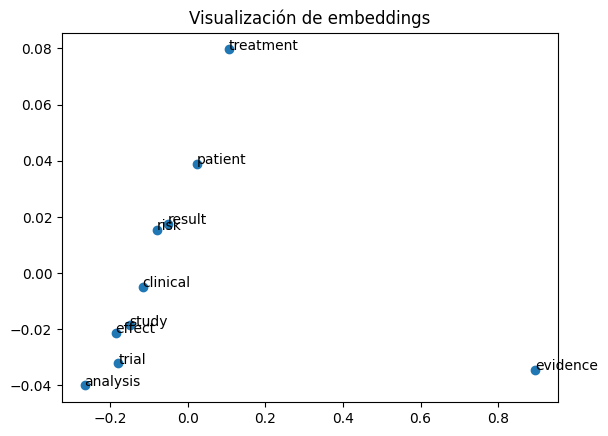

In [65]:
from sklearn.decomposition import PCA

vectors = [model.wv[w] for w in words_valid]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words_valid):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Visualización de embeddings")
plt.show()

### Visualización de embeddings

Se utilizó PCA para reducir la dimensionalidad de los vectores y visualizar las palabras en un espacio bidimensional.

Se observa que términos relacionados tienden a agruparse, lo cual indica que el modelo ha capturado relaciones semánticas dentro del corpus.

### Interpretación general

El análisis realizado muestra que:

- TF-IDF permite identificar las palabras más relevantes del corpus.
- Word2Vec permite analizar relaciones semánticas entre los términos.
- La visualización evidencia agrupaciones coherentes entre conceptos del dominio.

Esto resulta fundamental para etapas posteriores como sistemas de recuperación de información o arquitecturas RAG.

* El modelo identifica que "evidence" tiene un uso contextual muy distinto al resto de las palabras. Mientras las demás palabras suelen aparecer juntas en descripciones de procesos médicos, "evidence" probablemente aparece en secciones más abstractas o de validación científica.

* Observamos una línea casi perfecta que va desde abajo-izquierda hasta arriba-centro. Esto sugiere una jerarquía o flujo lógico que el modelo capturó:

1. **Fase de Investigación (Abajo):** analysis, trial, study, effect. Están muy cerca entre sí, lo que indica que el modelo las ve como casi sinónimos o términos que siempre van de la mano en la literatura técnica.

2. **Fase de Aplicación (Centro):** clinical, risk, result. Es el puente entre el estudio y el paciente.

3. **Fase Operativa/Paciente (Arriba):** patient y, en la cima, treatment.

# Users' Guides to the Medical Literature: A Manual for Evidence-Based Clinical Practice

In [66]:
ruta_pdf = "/content/drive/MyDrive/Corpus/Users Guides to the medical literature_A Manual for Evidence Based cience.pdf"

doc = fitz.open(ruta_pdf)

texto = ""

for pagina in doc:
    texto += pagina.get_text()

print(texto[:1000])

Notice
Medicine is an ever-changing science. As new research and clinical
experience broaden our knowledge, changes in treatment and drug therapy
are required. The authors and the publisher of this work have checked with
sources believed to be reliable in their efforts to provide information that is
complete and generally in accord with the standards accepted at the time of
publication. However, in view of the possibility of human error or changes in
medical sciences, neither the authors nor the publisher nor any other party
who has been involved in the preparation or publication of this work warrants
that the information contained herein is in every respect accurate or complete,
and they disclaim all responsibility for any errors or omissions or for the
results obtained from use of the information contained in this work. Readers
are encouraged to confirm the information contained herein with other
sources. For example and in particular, readers are advised to check the
product informa

## Análisis de Frecuencia de Palabras


1. Limpieza del texto

In [68]:
texto = texto.lower()

texto = re.sub(r'http\S+', '', texto)

# Eliminar caracteres raros (solo letras y espacios)
texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)

texto = re.sub(r'\s+', ' ', texto).strip()

print("Texto limpio:")
print(texto[:300])

Texto limpio:
notice medicine is an ever changing science as new research and clinical experience broaden our knowledge changes in treatment and drug therapy are required the authors and the publisher of this work have checked with sources believed to be reliable in their efforts to provide information that is co


2. Tokenización

In [69]:
tokens = word_tokenize(texto)

print("\nTokens iniciales:")
print(tokens[:30])


Tokens iniciales:
['notice', 'medicine', 'is', 'an', 'ever', 'changing', 'science', 'as', 'new', 'research', 'and', 'clinical', 'experience', 'broaden', 'our', 'knowledge', 'changes', 'in', 'treatment', 'and', 'drug', 'therapy', 'are', 'required', 'the', 'authors', 'and', 'the', 'publisher', 'of']


### 3. Eliminación de stopwords y ruido

In [70]:
stop_words = set(stopwords.words('english'))

tokens_limpios = [
    word for word in tokens
    if word not in stop_words and word.isalpha()
]

print("\nTokens limpios:")
print(tokens_limpios[:30])


Tokens limpios:
['notice', 'medicine', 'ever', 'changing', 'science', 'new', 'research', 'clinical', 'experience', 'broaden', 'knowledge', 'changes', 'treatment', 'drug', 'therapy', 'required', 'authors', 'publisher', 'work', 'checked', 'sources', 'believed', 'reliable', 'efforts', 'provide', 'information', 'complete', 'generally', 'accord', 'standards']


4. Lematización

In [71]:
lemmatizer = WordNetLemmatizer()

tokens_finales = [
    lemmatizer.lemmatize(word) for word in tokens_limpios
]

print("\nTokens lematizados:")
print(tokens_finales[:30])


Tokens lematizados:
['notice', 'medicine', 'ever', 'changing', 'science', 'new', 'research', 'clinical', 'experience', 'broaden', 'knowledge', 'change', 'treatment', 'drug', 'therapy', 'required', 'author', 'publisher', 'work', 'checked', 'source', 'believed', 'reliable', 'effort', 'provide', 'information', 'complete', 'generally', 'accord', 'standard']


In [72]:
frecuencias = Counter(tokens_finales)

top_20 = frecuencias.most_common(20)

print(top_20)

[('patient', 3290), ('study', 2093), ('trial', 1430), ('effect', 1425), ('result', 1407), ('clinical', 1352), ('treatment', 1259), ('analysis', 1235), ('evidence', 1228), ('risk', 1224), ('may', 1058), ('outcome', 1000), ('j', 857), ('group', 753), ('decision', 731), ('clinician', 712), ('test', 674), ('al', 660), ('review', 659), ('et', 651)]


In [73]:
total_frecuencias = sum(frecuencias.values())
total_unicas = len(frecuencias)

print(f"Total de palabras: {total_frecuencias}")
print(f"Total de palabras unicas: {total_unicas}")

Total de palabras: 169114
Total de palabras unicas: 12339


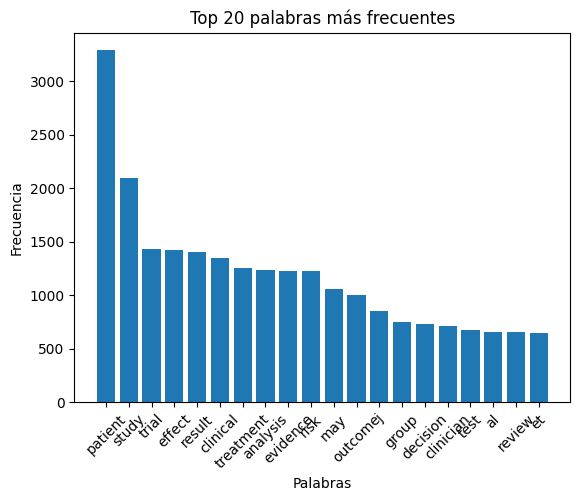

In [74]:
palabras = [w for w, f in top_20]
valores = [f for w, f in top_20]

plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=45)
plt.title("Top 20 palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.show()

### Resultados del análisis de frecuencia

En total se tienen 169.114 palabras en el corpus, de las cuales son palabras unicas 12.339.

Entre las palabras más relevantes se encuentran:

- "patients"
- "study"
- "trial"
- "effect"
- "results"
- "clinical"
- "treatment"

## Análisis Lingüístico del Corpus

In [77]:
# Lista de palabras de ruido
ruido = {
    'end', 'point', 'et', 'al', 'chapter'

}

# Filtrar tokens antes de hacer n-gramas
tokens_filtrados = [
    w for w in tokens_finales
    if w not in ruido and len(w) > 2
]

print(tokens_filtrados[:30])

['notice', 'medicine', 'ever', 'changing', 'science', 'new', 'research', 'clinical', 'experience', 'broaden', 'knowledge', 'change', 'treatment', 'drug', 'therapy', 'required', 'author', 'publisher', 'work', 'checked', 'source', 'believed', 'reliable', 'effort', 'provide', 'information', 'complete', 'generally', 'accord', 'standard']


In [78]:
bigramas = list(ngrams(tokens_filtrados, 2))

freq_bigramas = Counter(bigramas)

top_bigramas = freq_bigramas.most_common(10)

print(top_bigramas)

[(('meta', 'analysis'), 579), (('systematic', 'review'), 479), (('evidence', 'based'), 340), (('risk', 'bias'), 254), (('randomized', 'trial'), 247), (('treatment', 'effect'), 236), (('decision', 'making'), 221), (('clinical', 'trial'), 217), (('engl', 'med'), 171), (('myocardial', 'infarction'), 164)]


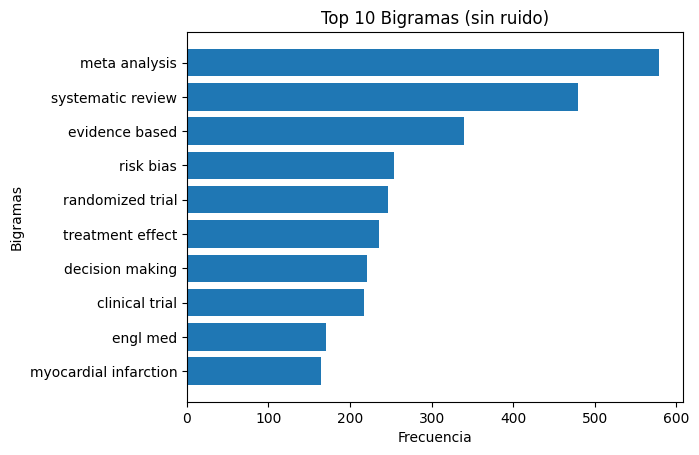

In [79]:
labels = [' '.join(bg) for bg, _ in top_bigramas]
values = [freq for _, freq in top_bigramas]

plt.figure()
plt.barh(labels, values)

plt.xlabel("Frecuencia")
plt.ylabel("Bigramas")
plt.title("Top 10 Bigramas (sin ruido)")

plt.gca().invert_yaxis()

plt.show()

Los resultados muestran combinaciones relevantes del dominio como "meta analysis","systematic review" "evidence based" y , las cuales son conceptos clave en el contexto de la medicina basada en evidencia.

Trigrama

In [80]:
# Crear trigramas
trigramas = list(ngrams(tokens_filtrados, 3))

# Frecuencias
freq_trigramas = Counter(trigramas)

# Top 10
top_trigramas = freq_trigramas.most_common(10)

print(top_trigramas)

[(('evidence', 'based', 'medicine'), 159), (('review', 'meta', 'analysis'), 126), (('systematic', 'review', 'meta'), 125), (('randomized', 'clinical', 'trial'), 124), (('patient', 'important', 'outcome'), 103), (('clinical', 'prediction', 'rule'), 102), (('ann', 'intern', 'med'), 90), (('decision', 'support', 'system'), 87), (('clinical', 'decision', 'support'), 85), (('clinical', 'practice', 'guideline'), 83)]


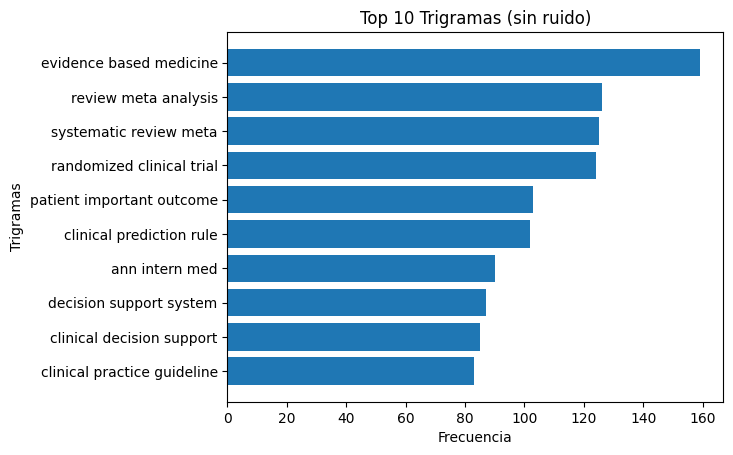

In [81]:
labels = [' '.join(tg) for tg, _ in top_trigramas]
values = [freq for _, freq in top_trigramas]

plt.figure()
plt.barh(labels, values)

plt.xlabel("Frecuencia")
plt.ylabel("Trigramas")
plt.title("Top 10 Trigramas (sin ruido)")

plt.gca().invert_yaxis()

plt.show()

Se encontraron combinaciones relevantes como  "evidence based medicine" ,"review meta analysis","randomized clinical trial", las cuales son conceptos relacionados en  la medicina basada en evidencia.

## Representación semántica y EDA avanzado

- TF-IDF: para identificar las palabras más relevantes del texto.
- Word2Vec: para analizar relaciones semánticas entre términos.


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

# convertir tokens a texto
texto_limpio = ' '.join(tokens_filtrados)

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([texto_limpio])

feature_names = vectorizer.get_feature_names_out()
scores = X.toarray()[0]

# top 10 palabras importantes
top_indices = np.argsort(scores)[-10:]
top_words = [(feature_names[i], scores[i]) for i in top_indices]

print(top_words)

[('risk', np.float64(0.16943157159294941)), ('evidence', np.float64(0.1699852695393316)), ('analysis', np.float64(0.1709542409455004)), ('treatment', np.float64(0.17427642862379356)), ('clinical', np.float64(0.18714990587717942)), ('result', np.float64(0.1947632526399345)), ('effect', np.float64(0.19725489339865432)), ('trial', np.float64(0.19794701583163207)), ('study', np.float64(0.28972245044447964)), ('patient', np.float64(0.4554165608993493))]


### Análisis con TF-IDF

Se aplicó TF-IDF para identificar las palabras más relevantes del corpus.

Los resultados muestran palabras clave del dominio como  "patient", "study", "trial" y "effect", lo cual confirma la temática del corpus.

In [83]:
from gensim.models import Word2Vec

sentences = [tokens_filtrados]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Modelo entrenado")

Modelo entrenado


In [84]:
# ordenar palabras por importancia
top_words_sorted = sorted(top_words, key=lambda x: x[1], reverse=True)

words = [w for w, _ in top_words_sorted]

# filtrar palabras que existen en el modelo
words_valid = [w for w in words if w in model.wv]

print(words_valid)

['patient', 'study', 'trial', 'effect', 'result', 'clinical', 'treatment', 'analysis', 'evidence', 'risk']


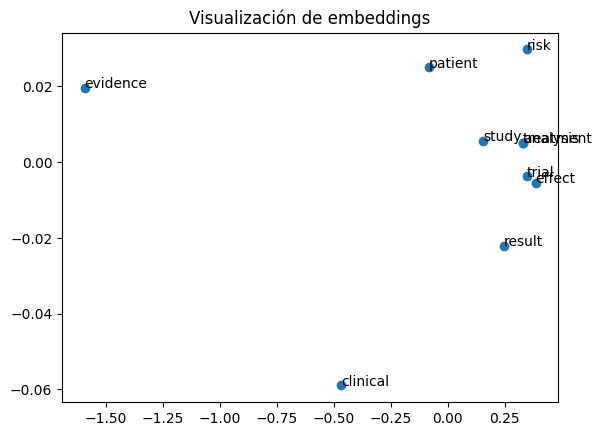

In [85]:
from sklearn.decomposition import PCA

vectors = [model.wv[w] for w in words_valid]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words_valid):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Visualización de embeddings")
plt.show()

## Conclusión corpus 2

* Se observan dos datos atipicos:

1. evidence: Está en el extremo izquierdo. Esto sugiere que en este libro, la "evidencia" se menciona de forma casi independiente a los procedimientos.

2. clinical: Está en el extremo inferior. Su gran distancia con el resto indica que se usa en un contexto muy específico (quizás puramente administrativo o técnico) que no se mezcla con las acciones directas sobre los pacientes.

* En este libro, el "tratamiento" se describe intrínsecamente como un "estudio" o un "ensayo". No hay una distinción clara entre investigar y tratar; parecen ser parte de la misma descripción procedimental. Es un enfoque mucho más experimental o académico que el anterior.

* patient y risk están en la parte superior derecha. Es notable que están más cerca entre ellos que del grupo de treatment. Esto indica que el libro probablemente asocia al "paciente" con la evaluación de "riesgos" de manera constante, quizás en un contexto de seguridad del paciente o diagnóstico preventivo.